# Task 5 — Scikit-Learn e scelta del modello finale

Confronto fra piu' classificatori, tuning, scelta finale. La sezione 8 mostra la procedura pronta
per `real_settings.csv`. Motivazioni: `documentation/05_modellazione.md`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, GridSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)

sns.set_theme(style="whitegrid")
SEME = 42

training = pd.read_csv("../data/training.csv").set_index("USERID")
y, X = training["ABBANDONO"], training.drop(columns="ABBANDONO")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, stratify=y, random_state=SEME)
CV = StratifiedKFold(5, shuffle=True, random_state=SEME)

print(f"training set: {len(y_tr)} studenti (positivi {y_tr.mean():.1%})")
print(f"test set    : {len(y_te)} studenti (positivi {y_te.mean():.1%})")

training set: 5628 studenti (positivi 57.7%)
test set    : 1407 studenti (positivi 57.7%)


## 1. Protocollo

Divisione 80/20 stratificata. Il test set si mette da parte **subito** e non si tocca fino alla
sezione 7: ogni scelta si fa in cross-validation sul solo training set.

Due riferimenti: baseline «sempre abbandona» **0,5771**, miglior classificatore costruito a mano
(Task 4) **0,7933**. Il secondo dice quanto valga usare Scikit-Learn invece di venti righe a mano.

In [2]:
baseline = cross_validate(DummyClassifier(strategy="most_frequent"), X_tr, y_tr, cv=CV,
                          scoring="accuracy")["test_score"]
MANUALE_T4 = 0.7933          # miglior configurazione del Task 4 (NB, soglie dalle medie di classe)

print(f"baseline (classe maggioritaria)        : {baseline.mean():.4f}")
print(f"miglior classificatore manuale (Task 4): {MANUALE_T4:.4f}")

baseline (classe maggioritaria)        : 0.5771
miglior classificatore manuale (Task 4): 0.7933


## 2. I classificatori in gara

Otto modelli con parametri di default. Lo scaling sta **dentro la `Pipeline`**, cosi' media e
deviazione standard si stimano sulle sole pieghe di addestramento.

In [3]:
def con_scaling(modello, scaler=None):
    return Pipeline([("scala", scaler or StandardScaler()), ("modello", modello)])

modelli = {
    "Perceptron":            con_scaling(Perceptron(random_state=SEME)),
    "Regressione logistica": con_scaling(LogisticRegression(max_iter=1000, random_state=SEME)),
    "k-NN (k=5)":            con_scaling(KNeighborsClassifier()),
    "SVC (RBF)":             con_scaling(SVC(random_state=SEME)),
    "Naive Bayes gaussiano": con_scaling(GaussianNB()),
    "Albero di decisione":   DecisionTreeClassifier(random_state=SEME),
    "Random Forest":         RandomForestClassifier(random_state=SEME),   # la parallelizzazione
    "Gradient Boosting":     HistGradientBoostingClassifier(random_state=SEME),  # la fa la CV esterna
}

righe = {}
for nome, modello in modelli.items():
    r = cross_validate(modello, X_tr, y_tr, cv=CV, scoring=["accuracy", "f1", "roc_auc"], n_jobs=-1)
    righe[nome] = {"accuratezza": r["test_accuracy"].mean(), "dev.std": r["test_accuracy"].std(),
                   "F1": r["test_f1"].mean(), "ROC-AUC": r["test_roc_auc"].mean()}
confronto = pd.DataFrame(righe).T.sort_values("accuratezza", ascending=False)
confronto.round(4)

,accuratezza,dev.std,F1,ROC-AUC
Regressione logistica,0.8074,0.0095,0.8389,0.8683
SVC (RBF),0.8072,0.0065,0.8401,0.8416
Gradient Boosting,0.8017,0.0056,0.8333,0.8585
Random Forest,0.7998,0.0093,0.8305,0.8628
Naive Bayes gaussiano,0.7944,0.0086,0.8232,0.8610
k-NN (k=5),0.7839,0.0073,0.8173,0.8310
Perceptron,0.7228,0.0683,0.7691,0.7763
Albero di decisione,0.7178,0.0191,0.7537,0.7108


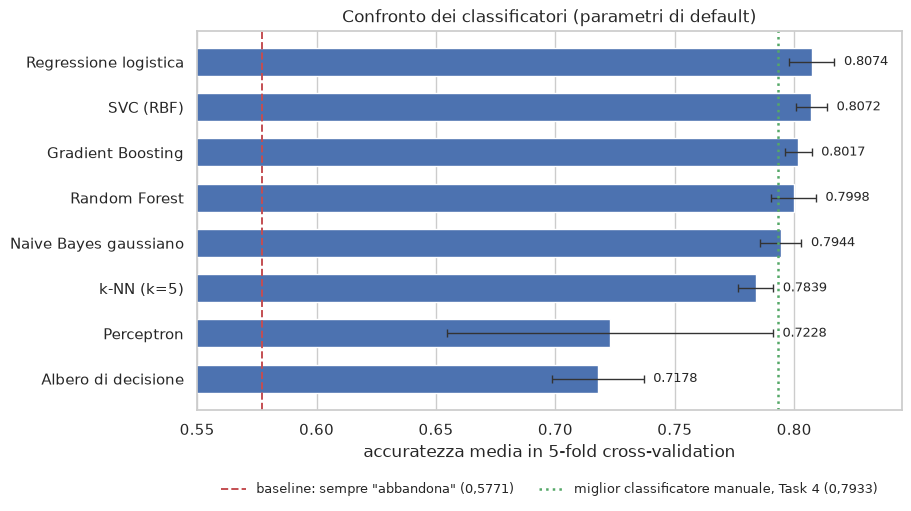

In [4]:
s = confronto["accuratezza"].sort_values()
fig, ax = plt.subplots(figsize=(9, 5.0), constrained_layout=True)
ax.barh(s.index, s.values, xerr=confronto.loc[s.index, "dev.std"], color="#4C72B0", height=.62,
        error_kw=dict(ecolor="#333", capsize=3, lw=1))
for i, (k, v) in enumerate(s.items()):
    ax.text(v + confronto.loc[k, "dev.std"] + .004, i, f"{v:.4f}", va="center", fontsize=9)
ax.axvline(baseline.mean(), color="#C44E52", ls="--", lw=1.4, label='baseline: sempre "abbandona" (0,5771)')
ax.axvline(MANUALE_T4, color="#55A868", ls=":", lw=1.8, label="miglior classificatore manuale, Task 4 (0,7933)")
ax.set_xlim(.55, .845); ax.set_xlabel("accuratezza media in 5-fold cross-validation")
ax.set_title("Confronto dei classificatori (parametri di default)")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.16), ncol=2, fontsize=9, frameon=False)
ax.grid(axis="y", visible=False)
plt.show()

**Tre modelli su otto fanno peggio del classificatore costruito a mano**, un quarto lo eguaglia.
L'albero senza limiti e' il peggiore; il Perceptron ha deviazione standard dieci volte gli altri —
i dati non sono linearmente separabili.

## 3. Le due domande lasciate aperte dal Task 3

In [5]:
scalatori = {"StandardScaler": StandardScaler(), "RobustScaler": RobustScaler(),
             "QuantileTransformer": QuantileTransformer(output_distribution="normal", random_state=SEME)}
prove = {}
for nome, base in [("Regressione logistica", LogisticRegression(max_iter=1000, random_state=SEME)),
                   ("SVC (RBF)", SVC(random_state=SEME))]:
    prove[nome] = {ns: cross_validate(con_scaling(base, s), X_tr, y_tr, cv=CV,
                                      scoring="accuracy", n_jobs=-1)["test_score"].mean()
                   for ns, s in scalatori.items()}
print("### quale scaler")
print(pd.DataFrame(prove).T.round(4).to_string())

### quale scaler
                       StandardScaler  RobustScaler  QuantileTransformer
Regressione logistica          0.8074        0.8074               0.7987
SVC (RBF)                      0.8072        0.8081               0.8060


In [6]:
INERTI = ["feature1_media", "feature2_media", "feature3_media"]
print("### servono le tre feature che il Task 3 aveva dichiarato prive di segnale?")
for nome in ["Regressione logistica", "Random Forest", "Gradient Boosting"]:
    m = modelli[nome]
    tutte   = cross_validate(m, X_tr, y_tr, cv=CV, scoring="accuracy", n_jobs=-1)["test_score"]
    ridotte = cross_validate(m, X_tr.drop(columns=INERTI), y_tr, cv=CV, scoring="accuracy", n_jobs=-1)["test_score"]
    d = tutte - ridotte
    print(f"  {nome:<24} 8 feature {tutte.mean():.4f}   5 feature {ridotte.mean():.4f}   "
          f"differenza {d.mean():+.4f}  ({int((d > 0).sum())}/5 pieghe a favore di 8)")

### servono le tre feature che il Task 3 aveva dichiarato prive di segnale?
  Regressione logistica    8 feature 0.8074   5 feature 0.8047   differenza +0.0027  (5/5 pieghe a favore di 8)


  Random Forest            8 feature 0.7998   5 feature 0.7916   differenza +0.0082  (3/5 pieghe a favore di 8)


  Gradient Boosting        8 feature 0.8017   5 feature 0.7969   differenza +0.0048  (3/5 pieghe a favore di 8)


**Due risultati negativi, riportati lo stesso.**

Lo scaler resistente agli outlier **non cambia niente**: `RobustScaler` da' lo stesso identico
punteggio. Il suggerimento del Task 3 era ragionevole ma sbagliato su questi dati — gli outlier sono
poche decine su 7.035.

Le tre feature «inerti» **contribuiscono**: toglierle peggiora tutti i modelli, per la regressione
logistica in 5 pieghe su 5. Scartare feature guardando la sola correlazione e' rischioso.

## 4. Ottimizzazione degli iperparametri

In [7]:
griglie = {
    "Regressione logistica": (con_scaling(LogisticRegression(max_iter=2000, random_state=SEME)),
                              {"modello__C": [.01, .1, 1, 10, 100]}),
    "SVC (RBF)":             (con_scaling(SVC(random_state=SEME)),
                              {"modello__C": [.5, 1, 5, 10], "modello__gamma": ["scale", .05, .1, .5]}),
    "Random Forest":         (RandomForestClassifier(random_state=SEME),
                              {"n_estimators": [300], "max_depth": [None, 8, 14], "min_samples_leaf": [1, 5, 20]}),
    "Gradient Boosting":     (HistGradientBoostingClassifier(random_state=SEME),
                              {"learning_rate": [.05, .1], "max_iter": [100, 300],
                               "max_leaf_nodes": [15, 31], "min_samples_leaf": [20, 50]}),
}
finalisti, tabella = {}, []
for nome, (stimatore, griglia) in griglie.items():
    gs = GridSearchCV(stimatore, griglia, cv=CV, scoring="accuracy", n_jobs=-1).fit(X_tr, y_tr)
    finalisti[nome] = gs.best_estimator_
    tabella.append({"modello": nome, "prima": round(confronto.loc[nome, "accuratezza"], 4),
                    "dopo": round(gs.best_score_, 4),
                    "guadagno": round(gs.best_score_ - confronto.loc[nome, "accuratezza"], 4),
                    "parametri": gs.best_params_})
pd.DataFrame(tabella).set_index("modello")

,prima,dopo,guadagno,parametri
modello,,,,
Regressione logistica,0.8074,0.8081,0.0007,{'modello__C': 0.1}
SVC (RBF),0.8072,0.8092,0.0020,"{'modello__C': 1, 'modello__gamma': 0.05}"
Random Forest,0.7998,0.8092,0.0094,"{'max_depth': None, 'min_samples_leaf': 20, 'n..."
Gradient Boosting,0.8017,0.8095,0.0078,"{'learning_rate': 0.05, 'max_iter': 100, 'max_..."


**Tutto converge.** I quattro modelli finiscono fra 0,8081 e 0,8095: 1,4 millesimi, contro una
deviazione standard di 0,009. Quando un confine lineare, un kernel RBF, 300 alberi e un boosting
arrivano allo stesso punto, il limite e' nei dati.

## 5. La soglia di decisione

In [8]:
prob = cross_val_predict(finalisti["Regressione logistica"], X_tr, y_tr, cv=CV, method="predict_proba")[:, 1]
soglie = pd.DataFrame([{"soglia": round(s, 2),
                        "accuratezza": round(accuracy_score(y_tr, (prob >= s).astype(int)), 4),
                        "F1": round(f1_score(y_tr, (prob >= s).astype(int)), 4)}
                       for s in np.arange(.30, .71, .05)])
print(soglie.to_string(index=False))
print(f"\nmiglior soglia per l'accuratezza: {soglie.loc[soglie.accuratezza.idxmax(), 'soglia']}")
print(f"miglior soglia per l'F1         : {soglie.loc[soglie.F1.idxmax(), 'soglia']}")

 soglia  accuratezza     F1
   0.30       0.7777 0.8296
   0.35       0.7923 0.8371
   0.40       0.8044 0.8432
   0.45       0.8065 0.8417
   0.50       0.8081 0.8396
   0.55       0.8044 0.8322
   0.60       0.7955 0.8197
   0.65       0.7870 0.8070
   0.70       0.7743 0.7883

miglior soglia per l'accuratezza: 0.5
miglior soglia per l'F1         : 0.4


0,5 e' gia' ottima per l'accuratezza; per l'F1 converrebbe 0,40. Manteniamo 0,5: la consegna non
indica un costo asimmetrico fra i due tipi di errore.

## 6. Analisi bias-varianza

Regressione logistica: validazione da 0.8061 (n=450) a 0.8081 (n=4502)   divario finale +0.0007


Gradient Boosting: validazione da 0.7976 (n=450) a 0.8090 (n=4502)   divario finale +0.0242


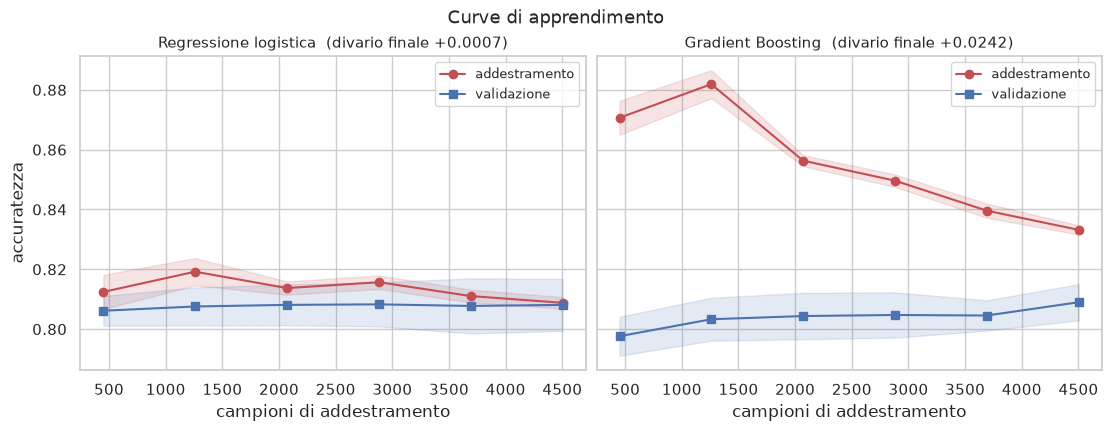

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True, sharey=True)
for ax, nome in zip(axes, ["Regressione logistica", "Gradient Boosting"]):
    n, tr, va = learning_curve(finalisti[nome], X_tr, y_tr, cv=CV, n_jobs=-1,
                               train_sizes=np.linspace(.1, 1., 6), scoring="accuracy")
    ax.plot(n, tr.mean(1), "o-", color="#C44E52", label="addestramento")
    ax.fill_between(n, tr.mean(1) - tr.std(1), tr.mean(1) + tr.std(1), color="#C44E52", alpha=.15)
    ax.plot(n, va.mean(1), "s-", color="#4C72B0", label="validazione")
    ax.fill_between(n, va.mean(1) - va.std(1), va.mean(1) + va.std(1), color="#4C72B0", alpha=.15)
    ax.set_title(f"{nome}  (divario finale {tr.mean(1)[-1] - va.mean(1)[-1]:+.4f})", fontsize=11)
    ax.set_xlabel("campioni di addestramento"); ax.legend(fontsize=9)
    print(f"{nome}: validazione da {va.mean(1)[0]:.4f} (n={int(n[0])}) a {va.mean(1)[-1]:.4f} "
          f"(n={int(n[-1])})   divario finale {tr.mean(1)[-1] - va.mean(1)[-1]:+.4f}")
axes[0].set_ylabel("accuratezza")
fig.suptitle("Curve di apprendimento", fontsize=13)
plt.show()

La regressione logistica ha le curve sovrapposte (divario **+0,0007**): regime di bias, nessun
sovradattamento. Ed e' **piatta gia' da 450 campioni** — piu' dati non servirebbero. Il Gradient
Boosting parte con un divario ampio e arriva allo stesso punto.

## 7. Scelta del modello finale

Solo adesso, a scelte fatte, si apre il test set.

In [10]:
esiti = []
for nome, modello in finalisti.items():
    modello.fit(X_tr, y_tr)
    p = modello.predict(X_te)
    prob_te = (modello.predict_proba(X_te)[:, 1] if hasattr(modello, "predict_proba")
               else modello.decision_function(X_te))
    esiti.append({"modello": nome, "CV": round(cross_validate(modello, X_tr, y_tr, cv=CV,
                                                              scoring="accuracy", n_jobs=-1)["test_score"].mean(), 4),
                  "test: accuratezza": round(accuracy_score(y_te, p), 4),
                  "test: F1": round(f1_score(y_te, p), 4),
                  "test: ROC-AUC": round(roc_auc_score(y_te, prob_te), 4)})
pd.DataFrame(esiti).set_index("modello").sort_values("test: accuratezza", ascending=False)

,CV,test: accuratezza,test: F1,test: ROC-AUC
modello,,,,
Regressione logistica,0.8081,0.7925,0.8272,0.8485
SVC (RBF),0.8092,0.7903,0.8255,0.8227
Gradient Boosting,0.8095,0.7903,0.8255,0.8520
Random Forest,0.8092,0.7882,0.8228,0.8552


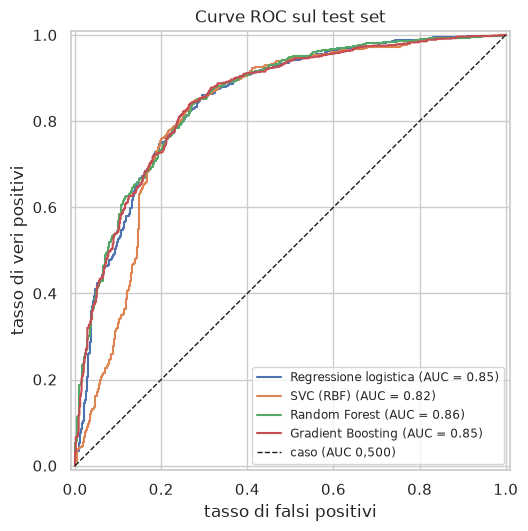

In [11]:
fig, ax = plt.subplots(figsize=(6, 5.2), constrained_layout=True)
for nome, modello in finalisti.items():
    RocCurveDisplay.from_estimator(modello, X_te, y_te, ax=ax, name=nome)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="caso (AUC 0,500)")
ax.set_xlabel("tasso di falsi positivi"); ax.set_ylabel("tasso di veri positivi")
ax.set_title("Curve ROC sul test set"); ax.legend(loc="lower right", fontsize=8.5)
plt.show()

**Modello scelto: regressione logistica** (`C = 0,1`, `StandardScaler`).

Le quattro alternative stanno in meno di mezzo punto sul test set, cioe' meno di una deviazione
standard: non c'e' un vincitore statistico. A parita' di prestazioni scegliamo la piu' semplice —
un iperparametro, nessun sovradattamento, coefficienti leggibili, nessuna dipendenza da seed.

              precision    recall  f1-score   support

    prosegue     0.7864    0.6992    0.7402       595
   abbandona     0.7961    0.8608    0.8272       812

    accuracy                         0.7925      1407
   macro avg     0.7913    0.7800    0.7837      1407
weighted avg     0.7920    0.7925    0.7904      1407



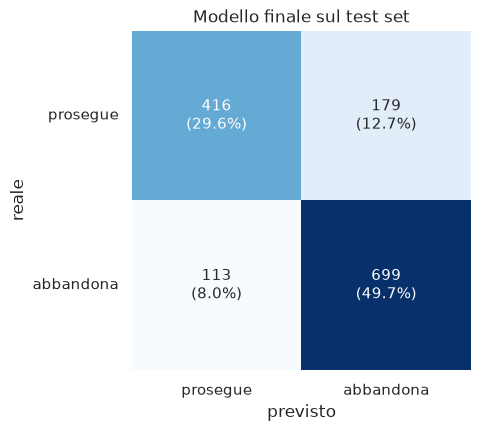

coefficienti (su feature standardizzate, quindi confrontabili fra loro):
n_attivita_distinte   -0.645
n_giorni_attivi       -0.644
n_azioni              -0.312
durata_giorni         -0.308
feature0_media        -0.299
feature2_media         0.038
feature1_media         0.141
feature3_media         0.203


In [12]:
finale = finalisti["Regressione logistica"]
pred = finale.predict(X_te)

print(classification_report(y_te, pred, target_names=["prosegue", "abbandona"], digits=4))

cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(6.0, 4.2), constrained_layout=True)
etichette = np.array([[f"{v}\n({v/cm.sum():.1%})" for v in riga] for riga in cm])
sns.heatmap(cm, annot=etichette, fmt="", cmap="Blues", cbar=False, square=True, ax=ax,
            xticklabels=["prosegue", "abbandona"], yticklabels=["prosegue", "abbandona"],
            annot_kws={"size": 11})
ax.set_xlabel("previsto"); ax.set_ylabel("reale"); ax.set_title("Modello finale sul test set")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.show()

coef = pd.Series(finale.named_steps["modello"].coef_[0], index=X.columns).sort_values()
print("coefficienti (su feature standardizzate, quindi confrontabili fra loro):")
print(coef.round(3).to_string())

Con correlazioni fino a 0,91 i coefficienti **non sono interpretabili singolarmente**: che
`n_attivita_distinte` pesi −0,645 e `n_azioni` −0,312 non significa che la prima conti il doppio, ma
che il modello ha distribuito fra due variabili quasi identiche un'unica quantita' di informazione.

## 8. Il file d'esame `real_settings.csv`

Le otto feature non esistono nel dataset originale, quindi il file va trasformato prima di darlo al
modello. `preprocessing.py` lo fa con la stessa funzione usata in addestramento e accetta entrambi i
formati. Proviamolo su un file finto di 200 studenti.

In [13]:
import tempfile, os
import preprocessing as pp

azioni = pp.carica_azioni()
scelti = np.random.default_rng(7).choice(azioni["USERID"].unique(), 200, replace=False)
cartella = tempfile.mkdtemp()
finto_log = os.path.join(cartella, "real_settings.csv")
azioni[azioni["USERID"].isin(scelti)].to_csv(finto_log, index=False)
finto_agg = os.path.join(cartella, "real_settings_aggregato.csv")
training.head(50).to_csv(finto_agg)

for descrizione, percorso in [("log di azioni", finto_log), ("gia' a livello studente", finto_agg)]:
    X_esame, y_esame = pp.carica_per_predire(percorso)
    p = finale.predict(X_esame)
    print(f"{descrizione:<24} -> {X_esame.shape[0]:4d} studenti, colonne corrette: "
          f"{list(X_esame.columns) == list(X.columns)}, accuratezza {accuracy_score(y_esame, p):.4f}")

log di azioni            ->  200 studenti, colonne corrette: True, accuratezza 0.8050
gia' a livello studente  ->   50 studenti, colonne corrette: True, accuratezza 0.8200


```python
import preprocessing as pp
X_esame, y_esame = pp.carica_per_predire("real_settings.csv")
previsioni = finale.predict(X_esame)
```

Il modello si riottiene rieseguendo il notebook, non e' salvato su disco: l'addestramento dura meno
di un secondo e cosi' non ci sono problemi di compatibilita' fra versioni di Scikit-Learn.

## 9. Limiti

- **Il guadagno su Scikit-Learn e' piccolo**: da 0,7933 a 0,8081, circa una deviazione standard e
  mezza.
- **Il tetto e' nei dati.** Tutti i modelli si fermano a 0,809; la curva di apprendimento e' piatta
  da 450 campioni; tre feature su otto sono quasi costanti nel dataset originale e le altre cinque
  correlate fino a 0,91.
- **Tautologia.** Su una finestra iniziale l'AUC crolla a 0,535 (appendice del Task 1). Il 79% vale
  sul problema come e' formulato dal dataset, non come previsione a corso in corso.